In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


In [14]:

# Load dataset
df = pd.read_csv("https://raw.githubusercontent.com/sundharhug24ad-cloud/exp1ml/refs/heads/main/Mall_Customers.csv")

# Display first 5 rows
print(df.head())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [15]:

# Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Elbow Method
inertia = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)
    inertia.append(model.inertia_)


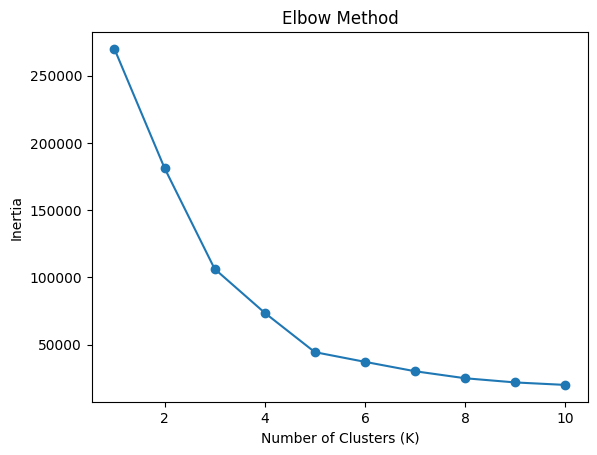

In [16]:

# Plot Elbow Curve
plt.plot(range(1, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [17]:
# Create K-Means model
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Train the model
kmeans.fit(X)


,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'



Cluster Centers:
[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Customer Segmentation:
     CustomerID  Annual Income (k$)  Spending Score (1-100)  Cluster
0             1                  15                      39        4
1             2                  15                      81        2
2             3                  16                       6        4
3             4                  16                      77        2
4             5                  17                      40        4
..          ...                 ...                     ...      ...
195         196                 120                      79        1
196         197                 126                      28        3
197         198                 126                      74        1
198         199                 137                      18        3
199         200                 137                      83    

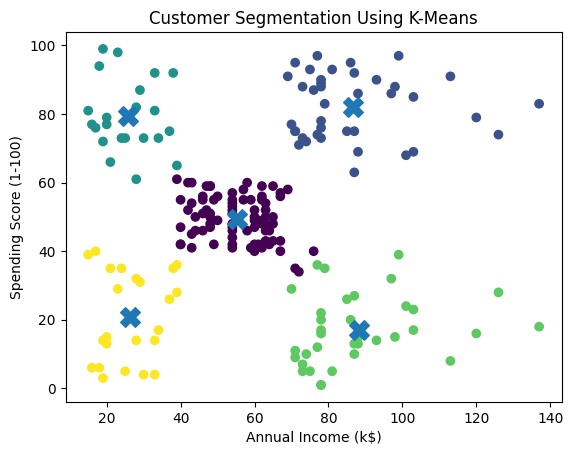

In [18]:

# Assign clusters
df["Cluster"] = kmeans.labels_

# Print cluster centers
print("\nCluster Centers:")
print(kmeans.cluster_centers_)

# Print customer segmentation
print("\nCustomer Segmentation:")
print(df[[
    "CustomerID",
    "Annual Income (k$)",
    "Spending Score (1-100)",
    "Cluster"
]])

# Visualize clusters
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"]
)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation Using K-Means")

plt.show()